# Lesson 3.2 — The Representation Map B(φ)
**Module 6 · Unit 3 · Lesson 10**

$B(\boldsymbol\phi)$ converts angle-rates to true angular velocity: $\boldsymbol\omega=B(\boldsymbol\phi)\dot{\boldsymbol\phi}$, with columns $(\partial R/\partial\phi_k\,R^\top)^\vee$. We verify this and $J_\omega=B J_\phi$, then watch $\det B\to0$ at gimbal lock.

In [1]:
import numpy as np
def skew(v):
    v=np.asarray(v,float).ravel(); return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])
def vee(S): return np.array([S[2,1],S[0,2],S[1,0]])
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i])
        M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def pose(P,T,q):
    M=forward_chain(P,T,q)[-1]; return M[:3,3], M[:3,:3]

# ZYX roll-pitch-yaw
def rpy_from_R(R):
    return np.array([np.arctan2(R[2,1],R[2,2]),
                     np.arctan2(-R[2,0],np.hypot(R[2,1],R[2,2])),
                     np.arctan2(R[1,0],R[0,0])])   # [roll, pitch, yaw]
def R_from_rpy(rpy):
    r,p,y=rpy
    Rz=np.array([[np.cos(y),-np.sin(y),0],[np.sin(y),np.cos(y),0],[0,0,1.0]])
    Ry=np.array([[np.cos(p),0,np.sin(p)],[0,1,0],[-np.sin(p),0,np.cos(p)]])
    Rx=np.array([[1,0,0],[0,np.cos(r),-np.sin(r)],[0,np.sin(r),np.cos(r)]])
    return Rz@Ry@Rx

# spatial 3R test arm
ARM=([(0,0,0,np.pi/2),(0,0,1.0,0),(0,0,0.8,0)],["R","R","R"])


## Build $B(\boldsymbol\phi)$: each column is a unit-dial angular velocity

In [2]:
checks=[]
def Bmat(rpy,eps=1e-7):
    R=R_from_rpy(rpy); B=np.zeros((3,3))
    for k in range(3):
        e=np.zeros(3); e[k]=eps
        dR=(R_from_rpy(rpy+e)-R_from_rpy(rpy-e))/(2*eps)
        B[:,k]=vee(dR@R.T)
    return B
phi=np.array([0.3,-0.4,1.1]); print("B(phi) =\n",np.round(Bmat(phi),3))

B(phi) =
 [[ 0.418 -0.891  0.   ]
 [ 0.821  0.454 -0.   ]
 [ 0.389 -0.     1.   ]]


## Verify $\boldsymbol\omega = B\,\dot{\boldsymbol\phi}$ and $J_\omega = B J_\phi$

In [3]:
P,T=ARM; q=np.array([0.4,0.6,-0.3])
def analytic_jacobian(P,T,q,eps=1e-6):
    n=len(q); J=np.zeros((6,n))
    for i in range(n):
        e=np.zeros(n); e[i]=eps
        pp,Rp=pose(P,T,q+e); pm,Rm=pose(P,T,q-e)
        J[:,i]=(np.hstack([pp,rpy_from_R(Rp)])-np.hstack([pm,rpy_from_R(Rm)]))/(2*eps)
    return J
Jg=geometric_jacobian(P,T,q); Ja=analytic_jacobian(P,T,q)
p,Rc=pose(P,T,q); B=Bmat(rpy_from_R(Rc))
qd=np.array([0.7,-1.1,0.5])
omega_geo=Jg[3:,:]@qd; phidot=Ja[3:,:]@qd
print("omega (geometric):",np.round(omega_geo,4))
print("B @ phidot       :",np.round(B@phidot,4))
checks.append(np.allclose(omega_geo,B@phidot,atol=1e-4))
checks.append(np.allclose(Jg[3:,:],B@Ja[3:,:],atol=1e-4))

omega (geometric): [-0.2337  0.5526  0.7   ]
B @ phidot       : [-0.2337  0.5526  0.7   ]


## $\det B \to 0$ at gimbal lock (pitch → 90°)

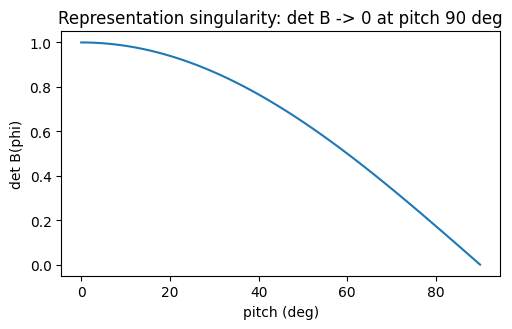

det B at pitch~90: 0.001  at pitch 0: 1.0


In [4]:
import matplotlib.pyplot as plt
pitches=np.linspace(0,np.pi/2-1e-3,60)
dets=[np.linalg.det(Bmat(np.array([0.2,p,0.5]))) for p in pitches]
plt.figure(figsize=(5.2,3.4)); plt.plot(np.degrees(pitches),dets)
plt.xlabel("pitch (deg)"); plt.ylabel("det B(phi)"); plt.title("Representation singularity: det B -> 0 at pitch 90 deg")
plt.tight_layout(); plt.show()
checks.append(abs(dets[-1])<1e-2 and abs(dets[0])>0.5)
print("det B at pitch~90:",round(dets[-1],4)," at pitch 0:",round(dets[0],4))

In [5]:
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

All checks passed.
